### **CC57 - MACHINE LEARNING - PREPROCESAMIENTO DE DATOS**

**Nombres / Apellidos:**


**Código:**

---

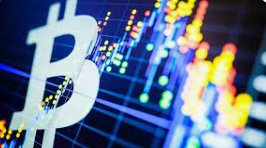

El dataset global de criptomonedas es un conjunto de datos completo  que ofrece una gran cantidad de información sobre más de 7500 criptomonedas, cada una de ellas combinada con el dólar estadounidense (USD). Este conjunto de datos es un recurso invaluable para cualquier persona interesada en explorar el mundo de las monedas digitales y analizar su comportamiento en el mercado. Estos no solo incluyen monedas populares como BTC, ETH y SOL, sino que también capturan monedas recién lanzadas.

**Estructura del Dataset**

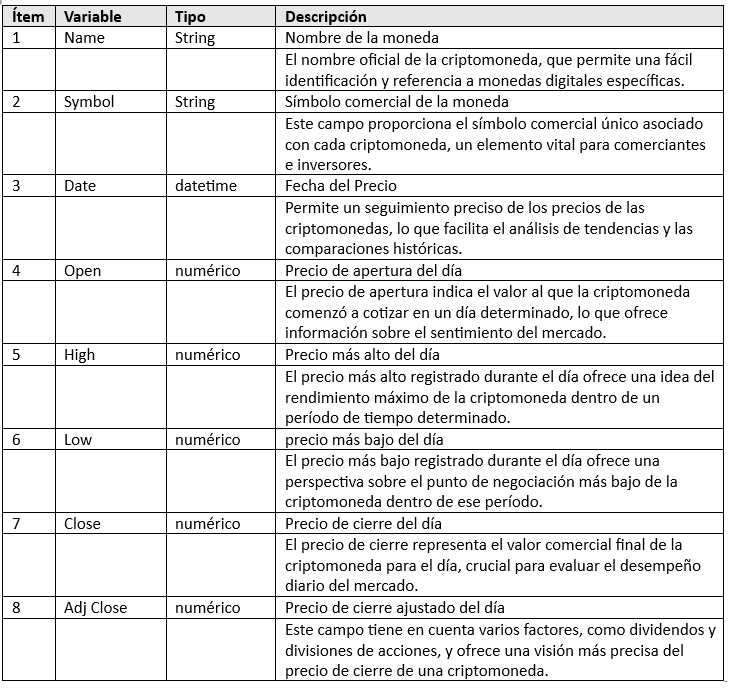

**SE SOLICITA:**

**a)**Cargar los datos

**b)** Realizar tareas de preprocesamiento sobre los datos

**c)**Crear un dataset limpio

**d)** Realizar un analisis EDA (considere las visualizaciones que crea necesarias).

# 1. Introduccion

Analsis EDA (Analisis Exploratorio de Datos)

# 2. Importar las Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3, Cargar los Datos

In [ ]:
import sys

criptomoneda = 'ETHO'

if 'google.colab' in sys.modules:
    df = pd.read_csv(f'https://raw.githubusercontent.com/dReposU/ML/main/Sem_1/Ejercicio-Preprocesamiento/data/{criptomoneda}-USD.csv')
else:
    df = pd.read_csv(f'data/{criptomoneda}-USD.csv')
df.head()

,Name,Symbol,Date,Open,High,Low,Close,Adj Close,Volume
0,Etho Protocol USD,ETHO-USD,2018-10-17,0.022328,0.030765,0.022186,0.027731,0.027731,15512
1,Etho Protocol USD,ETHO-USD,2018-10-18,0.027840,0.027840,0.022163,0.022925,0.022925,4069
2,Etho Protocol USD,ETHO-USD,2018-10-19,0.022922,0.026737,0.022922,0.025665,0.025665,4669
3,Etho Protocol USD,ETHO-USD,2018-10-20,0.025657,0.027831,0.024544,0.026298,0.026298,4951
4,Etho Protocol USD,ETHO-USD,2018-10-21,0.026304,0.027966,0.025567,0.026964,0.026964,3595


# 4. Exploracion Inicial

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834 entries, 0 to 1833
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Name       1834 non-null   object 
 1   Symbol     1834 non-null   object 
 2   Date       1834 non-null   object 
 3   Open       1834 non-null   float64
 4   High       1834 non-null   float64
 5   Low        1834 non-null   float64
 6   Close      1834 non-null   float64
 7   Adj Close  1834 non-null   float64
 8   Volume     1834 non-null   int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 129.1+ KB


In [ ]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1834.000000,1834.000000,1834.000000,1834.000000,1834.000000,1.834000e+03
mean,0.030117,0.033503,0.027142,0.030105,0.030105,1.622653e+05
std,0.042063,0.046954,0.038216,0.042072,0.042072,3.493512e+05
min,0.001011,0.001328,0.000975,0.001019,0.001019,2.121000e+03
25%,0.006072,0.006608,0.005395,0.006054,0.006054,1.823900e+04
50%,0.010581,0.011762,0.009343,0.010590,0.010590,5.085700e+04
75%,0.032410,0.035952,0.028385,0.032399,0.032399,2.726910e+05
max,0.250304,0.328181,0.219447,0.250371,0.250371,8.449910e+06


# Limpieza y Transformación

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(by="Date")

df.isnull().sum()

,0
Name,0
Symbol,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


# 6. Analisis Univariado

Distribucion del Precio de Cierre

In [ ]:
df

,Name,Symbol,Date,Open,High,Low,Close,Adj Close,Volume
0,Etho Protocol USD,ETHO-USD,2018-10-17,0.022328,0.030765,0.022186,0.027731,0.027731,15512
1,Etho Protocol USD,ETHO-USD,2018-10-18,0.027840,0.027840,0.022163,0.022925,0.022925,4069
2,Etho Protocol USD,ETHO-USD,2018-10-19,0.022922,0.026737,0.022922,0.025665,0.025665,4669
3,Etho Protocol USD,ETHO-USD,2018-10-20,0.025657,0.027831,0.024544,0.026298,0.026298,4951
4,Etho Protocol USD,ETHO-USD,2018-10-21,0.026304,0.027966,0.025567,0.026964,0.026964,3595
...,...,...,...,...,...,...,...,...,...
1829,Etho Protocol USD,ETHO-USD,2023-10-20,0.001529,0.001678,0.001473,0.001532,0.001532,50214
1830,Etho Protocol USD,ETHO-USD,2023-10-21,0.001452,0.001613,0.001450,0.001472,0.001472,42193
1831,Etho Protocol USD,ETHO-USD,2023-10-22,0.001576,0.001734,0.001471,0.001584,0.001584,38850
1832,Etho Protocol USD,ETHO-USD,2023-10-23,0.001616,0.001686,0.001550,0.001600,0.001600,46157


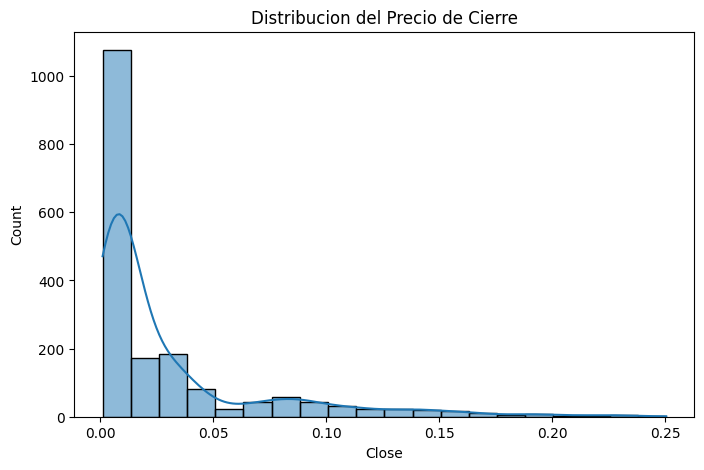

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Close"], bins=20, kde=True)
plt.title("Distribucion del Precio de Cierre")
plt.show()

Deteccion de Outliers

In [ ]:
df["Close"].describe()

,Close
count,1834.000000
mean,0.030105
std,0.042072
min,0.001019
25%,0.006054
50%,0.010590
75%,0.032399
max,0.250371


In [ ]:
df["Close"].quantile(0.75)

np.float64(0.032398749142885125)

In [ ]:
df["Close"].median()

0.01059049973264335

BoxSplot

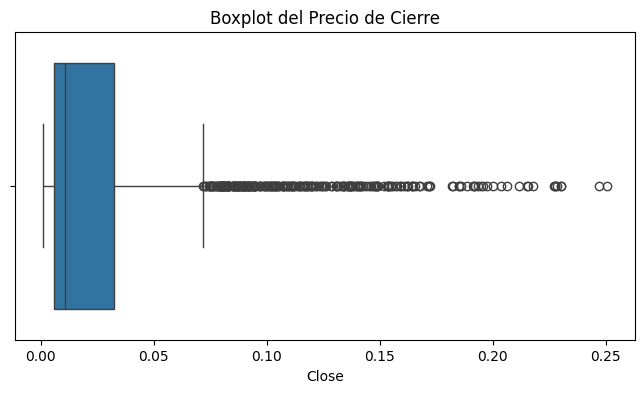

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Close"])
plt.title("Boxplot del Precio de Cierre")
plt.show()

Evolucion del Precio Cierre en el Tiempo

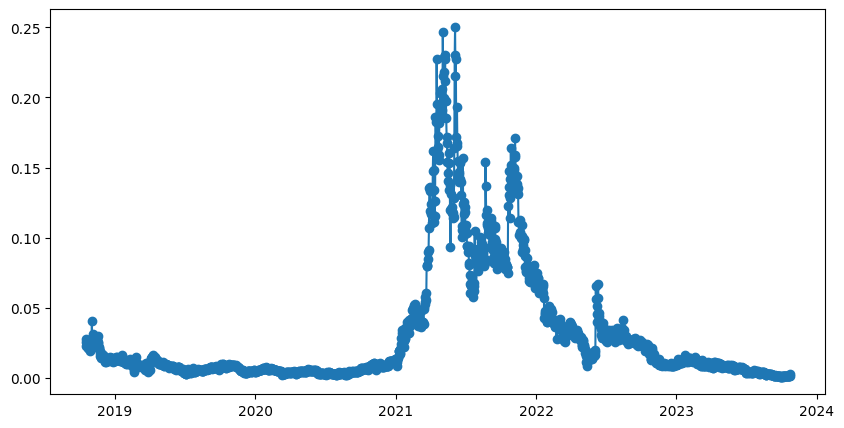

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Close"], marker="o")
plt.show()

# Correlacion entre variables

Matriz de Correlacion

In [ ]:
numeric_labels = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
corr = df[numeric_labels].corr()
corr

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.987811,0.995603,0.988499,0.988499,0.405971
High,0.987811,1.000000,0.985784,0.993678,0.993678,0.471408
Low,0.995603,0.985784,1.000000,0.991897,0.991897,0.394846
Close,0.988499,0.993678,0.991897,1.000000,1.000000,0.431108
Adj Close,0.988499,0.993678,0.991897,1.000000,1.000000,0.431108
Volume,0.405971,0.471408,0.394846,0.431108,0.431108,1.000000


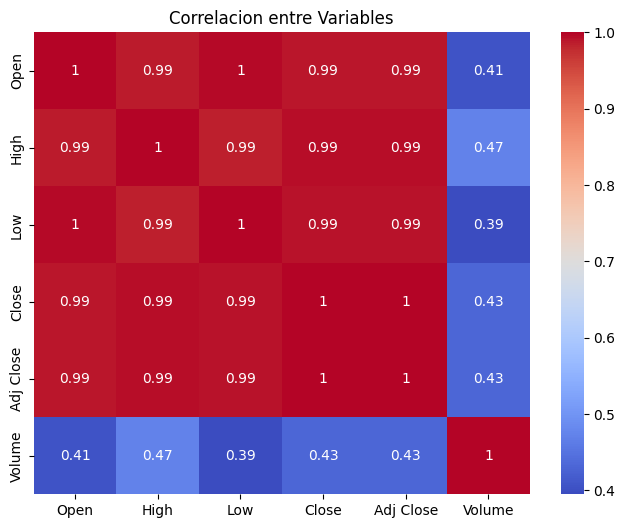

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlacion entre Variables")
plt.show()

Relacion Volumen vs Precio

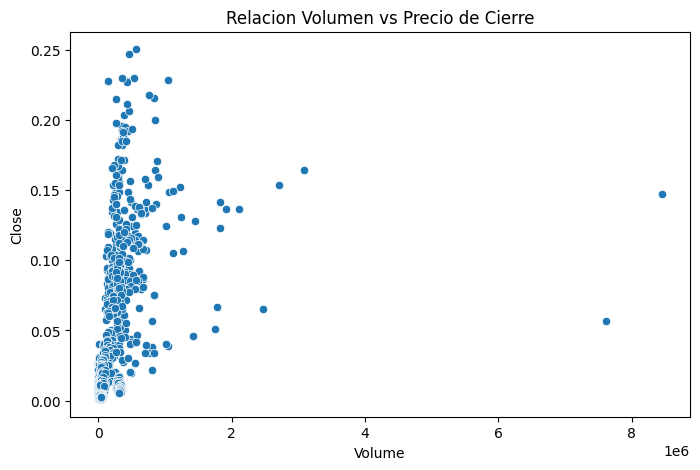

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Volume"], y=df["Close"])
plt.title("Relacion Volumen vs Precio de Cierre")
plt.show()

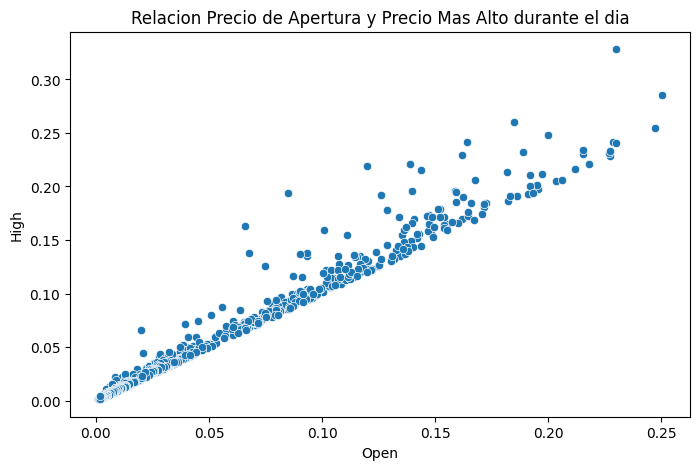

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Open"], y=df["High"])
plt.title("Relacion Precio de Apertura y Precio Mas Alto durante el dia")
plt.show()